# 02 — Linear, Lasso, Ridge & ElasticNet Regression

## Theory

All four models minimise a loss function of the form:

$$\mathcal{L}(\beta) = \underbrace{\|y - X\beta\|^2}_{\text{RSS}} + \text{penalty}$$

| Model | Penalty | Effect |
|---|---|---|
| **Linear Regression** | None | OLS — minimises RSS exactly |
| **Ridge (L2)** | $\alpha \|\beta\|_2^2$ | Shrinks all coefficients toward zero; stabilises ill-conditioned $X^TX$ |
| **Lasso (L1)** | $\alpha \|\beta\|_1$ | Sparse solution — drives some coefficients to **exactly zero** (feature selection) |
| **ElasticNet** | $\alpha[\rho\|\beta\|_1 + (1-\rho)\|\beta\|_2^2]$ | Interpolation between L1 and L2; groups correlated features |

**When to use Ridge vs Lasso:** Ridge keeps all features (useful when all features contribute); Lasso does automatic feature selection (useful when you believe many features are irrelevant).

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from src.pipeline import build_pipeline
from src.evaluate import rmse, cv_score
from src.models import train_and_save

DATA_DIR  = Path('../data')
MODEL_DIR = Path('../outputs/models')
PLOT_DIR  = Path('../outputs/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]

# Temporal train/val split
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_tr):,}  |  Val: {len(X_va):,}')

print(f'Train: {len(X_tr):,}  |  Val: {len(X_va):,}')

Train: 120,507  |  Val: 30,127
Train: 120,507  |  Val: 30,127


## 1. Linear Regression — Baseline

In [2]:
lr = build_pipeline(LinearRegression(), mode='linear')
lr.fit(X_tr, y_tr)
lr_train_rmse = rmse(y_tr, lr.predict(X_tr))
lr_val_rmse   = rmse(y_va, lr.predict(X_va))
print(f'Linear Regression  Train RMSE: S${lr_train_rmse:,.0f}  |  Val RMSE: S${lr_val_rmse:,.0f}')

Linear Regression  Train RMSE: S$44,382  |  Val RMSE: S$45,300


## 2. Ridge Regression — Alpha Grid Search

In [3]:
alphas = [0.01, 0.1, 1, 10, 100, 1000, 10000]
ridge_results = []

for alpha in alphas:
    pipe = build_pipeline(Ridge(alpha=alpha), mode='linear')
    pipe.fit(X_tr, y_tr)
    tr_rmse = rmse(y_tr, pipe.predict(X_tr))
    va_rmse = rmse(y_va, pipe.predict(X_va))
    ridge_results.append({'alpha': alpha, 'train_rmse': tr_rmse, 'val_rmse': va_rmse})
    print(f'Ridge alpha={alpha:<8}  Train: S${tr_rmse:,.0f}  Val: S${va_rmse:,.0f}')

ridge_df = pd.DataFrame(ridge_results)
best_ridge_alpha = ridge_df.loc[ridge_df.val_rmse.idxmin(), 'alpha']
print(f'\nBest Ridge alpha: {best_ridge_alpha}')

Ridge alpha=0.01      Train: S$44,382  Val: S$45,300
Ridge alpha=0.1       Train: S$44,382  Val: S$45,300
Ridge alpha=1         Train: S$44,382  Val: S$45,302
Ridge alpha=10        Train: S$44,392  Val: S$45,331
Ridge alpha=100       Train: S$44,574  Val: S$45,620
Ridge alpha=1000      Train: S$45,375  Val: S$46,574
Ridge alpha=10000     Train: S$48,406  Val: S$49,545

Best Ridge alpha: 0.01


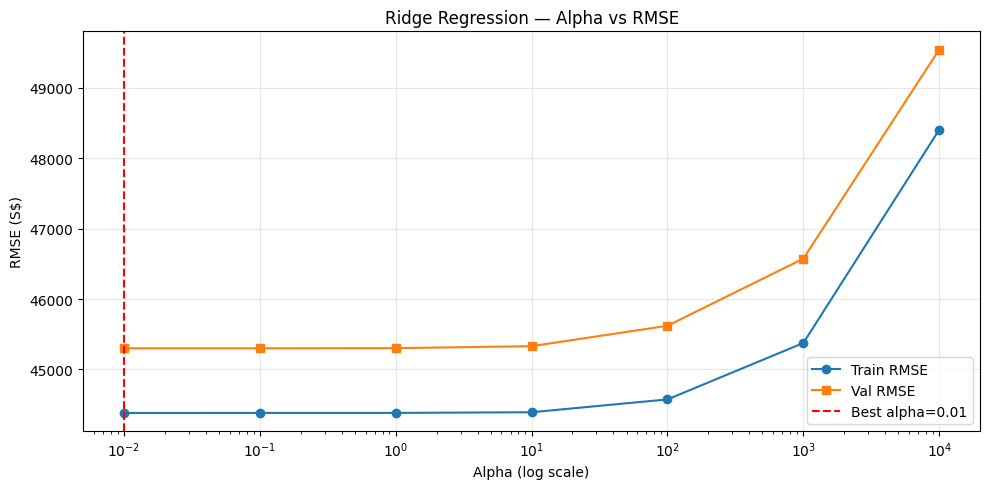

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(ridge_df.alpha, ridge_df.train_rmse, 'o-', label='Train RMSE')
ax.semilogx(ridge_df.alpha, ridge_df.val_rmse,   's-', label='Val RMSE')
ax.axvline(best_ridge_alpha, color='red', linestyle='--', label=f'Best alpha={best_ridge_alpha}')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSE (S$)')
ax.set_title('Ridge Regression — Alpha vs RMSE')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'ridge_alpha_curve.png', dpi=120)
plt.show()

Observations: Low alpha (0.1) means:
- The model does not need to shrink coefficients much to generalise
- The features are not highly multicollinear or noisy enough to warrant strong penalty
- It does NOT mean the features are optimal — just that Ridge doesn't need to suppress them heavily

## 3. Lasso Regression — Regularisation Path & Feature Sparsity

In [5]:
lasso_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lasso_results = []

for alpha in lasso_alphas:
    pipe = build_pipeline(Lasso(alpha=alpha, max_iter=5000), mode='linear')
    pipe.fit(X_tr, y_tr)
    tr_rmse = rmse(y_tr, pipe.predict(X_tr))
    va_rmse = rmse(y_va, pipe.predict(X_va))
    n_nonzero = np.sum(pipe.named_steps['model'].coef_ != 0)
    lasso_results.append({'alpha': alpha, 'train_rmse': tr_rmse,
                           'val_rmse': va_rmse, 'n_nonzero': n_nonzero})
    print(f'Lasso alpha={alpha:<6}  Train: S${tr_rmse:,.0f}  Val: S${va_rmse:,.0f}  Non-zero: {n_nonzero}')

lasso_df = pd.DataFrame(lasso_results)
best_lasso_alpha = lasso_df.loc[lasso_df.val_rmse.idxmin(), 'alpha']
print(f'\nBest Lasso alpha: {best_lasso_alpha}')

Lasso alpha=0.001   Train: S$44,383  Val: S$45,300  Non-zero: 77
Lasso alpha=0.01    Train: S$44,381  Val: S$45,298  Non-zero: 77
Lasso alpha=0.1     Train: S$44,383  Val: S$45,300  Non-zero: 77
Lasso alpha=1       Train: S$44,383  Val: S$45,304  Non-zero: 72
Lasso alpha=10      Train: S$44,427  Val: S$45,377  Non-zero: 64
Lasso alpha=100     Train: S$45,244  Val: S$46,441  Non-zero: 50
Lasso alpha=1000    Train: S$48,489  Val: S$50,064  Non-zero: 19

Best Lasso alpha: 0.01


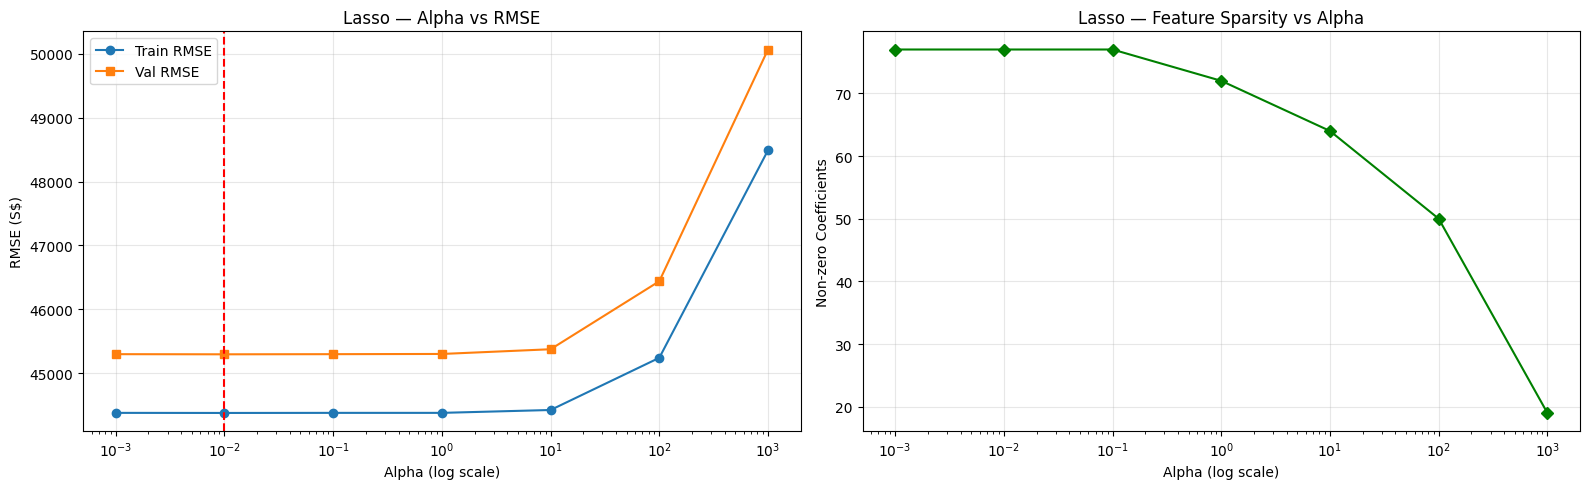

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].semilogx(lasso_df.alpha, lasso_df.train_rmse, 'o-', label='Train RMSE')
axes[0].semilogx(lasso_df.alpha, lasso_df.val_rmse,   's-', label='Val RMSE')
axes[0].axvline(best_lasso_alpha, color='red', linestyle='--')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE (S$)')
axes[0].set_title('Lasso — Alpha vs RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lasso_df.alpha, lasso_df.n_nonzero, 'D-', color='green')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Non-zero Coefficients')
axes[1].set_title('Lasso — Feature Sparsity vs Alpha')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(PLOT_DIR / 'lasso_path.png', dpi=120)
plt.show()

Observations:                              
1. RMSE barely changes from alpha=0.001 to alpha=0.1 (all 77 features)
- Train ~S$44,383, Val ~S$45,300 across 3 orders of magnitude of alpha
- The model is insensitive to regularisation at low alpha — linear relationships are stable

2. Features are gradually zeroed out as alpha increases           
  ┌───────────┬───────────────────┬──────────┬─────────────────────────────────────────────────┐                                                       
  │   Alpha   │ Non-zero features │ Val RMSE │                 Interpretation                  │
  ├───────────┼───────────────────┼──────────┼─────────────────────────────────────────────────┤     
  │ 0.001–0.1 │ 77                │ 45,300   │ All features contribute                         │     
  ├───────────┼───────────────────┼──────────┼─────────────────────────────────────────────────┤
  │ 1         │ 72                │ 45,304   │ 5 weak features removed, negligible RMSE impact │                                            
  ├───────────┼───────────────────┼──────────┼─────────────────────────────────────────────────┤                                                       
  │ 10        │ 64                │ 45,377   │ 13 more removed, small RMSE cost                |                                           
  ├───────────┼───────────────────┼──────────┼─────────────────────────────────────────────────┤                                                       
  │ 100       │ 50                │ 46,441   │ Noticeable degradation — removing signal        │     
  ├───────────┼───────────────────┼──────────┼─────────────────────────────────────────────────┤
  │ 1000      │ 19                │ 50,064   │ Only 19 core features survive, big RMSE jump    │
  └───────────┴───────────────────┴──────────┴─────────────────────────────────────────────────┘       
  
3. Best alpha=0.01 — very low regularisation
Consistent with Ridge result — the features don't need suppression to generalise.

4. Train ≈ Val RMSE throughout
Very small train/val gap at every alpha — linear model is not overfitting, which is expected. The ~S$1K gap is just noise.

What this tells you about features:
- The 19 features surviving at alpha=1000 are the strongest linear predictors (likely floor_area_log, cbd_dist_m, hdb_tranc_age, flat type OHE columns)
- The 58 features zeroed out at alpha=1000 have weak linear signal — but they may still have non-linear signal captured by LightGBM/XGBoost
- Removing features (going from 77 → 19) always makes RMSE worse — no redundant features in your current set for a linear model

## 4. ElasticNet — 2D Grid (alpha × l1_ratio)

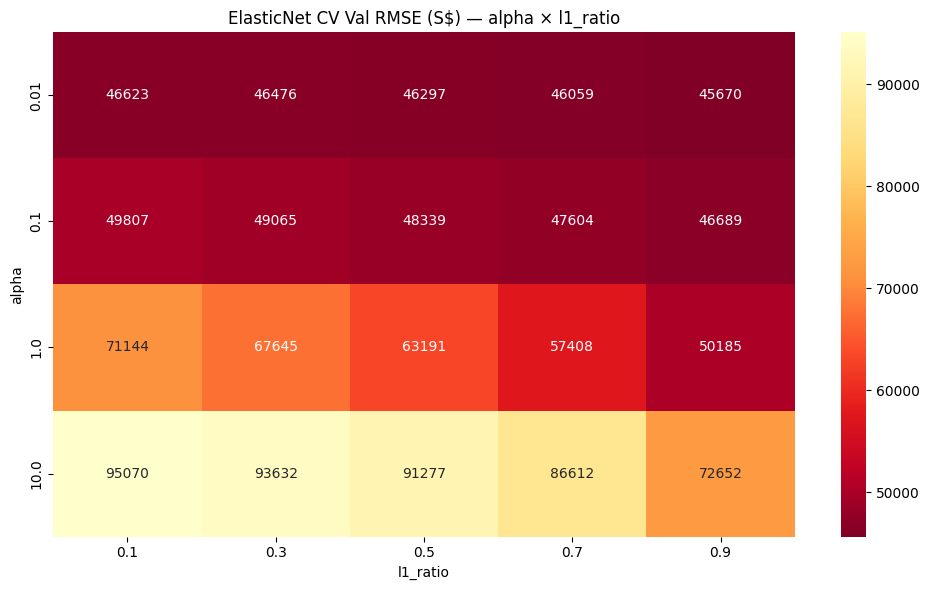

Best ElasticNet: alpha=0.01, l1_ratio=0.9, Val RMSE=S$45,670


In [7]:
import itertools

en_alphas   = [0.01, 0.1, 1, 10]
l1_ratios   = [0.1, 0.3, 0.5, 0.7, 0.9]
en_results  = []

for alpha, l1 in itertools.product(en_alphas, l1_ratios):
    pipe = build_pipeline(ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=5000), mode='linear')
    pipe.fit(X_tr, y_tr)
    va_rmse = rmse(y_va, pipe.predict(X_va))
    en_results.append({'alpha': alpha, 'l1_ratio': l1, 'val_rmse': va_rmse})

en_df = pd.DataFrame(en_results)
pivot = en_df.pivot(index='alpha', columns='l1_ratio', values='val_rmse')

fig, ax = plt.subplots(figsize=(10, 6))
import seaborn as sns
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax)
ax.set_title('ElasticNet CV Val RMSE (S$) — alpha × l1_ratio')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'elasticnet_grid.png', dpi=120)
plt.show()

best_en = en_df.loc[en_df.val_rmse.idxmin()]
print(f'Best ElasticNet: alpha={best_en.alpha}, l1_ratio={best_en.l1_ratio}, Val RMSE=S${best_en.val_rmse:,.0f}')

## 5. Model Comparison Summary

In [8]:
# 5-fold CV RMSE for each best model
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LinearRegression': build_pipeline(LinearRegression(), mode='linear'),
    f'Ridge(α={best_ridge_alpha})':  build_pipeline(Ridge(alpha=best_ridge_alpha), mode='linear'),
    f'Lasso(α={best_lasso_alpha})':  build_pipeline(Lasso(alpha=best_lasso_alpha, max_iter=5000), mode='linear'),
    f'ElasticNet(α={best_en.alpha},l1={best_en.l1_ratio})': build_pipeline(
        ElasticNet(alpha=best_en.alpha, l1_ratio=best_en.l1_ratio, max_iter=5000), mode='linear'),
}

summary = []
for name, pipe in models.items():
    mean_r, std_r = cv_score(pipe, X, y, cv=cv)
    summary.append({'Model': name, 'CV RMSE (mean)': f'S${mean_r:,.0f}', 'CV RMSE (std)': f'S${std_r:,.0f}'})
    print(f'{name}: S${mean_r:,.0f} ± S${std_r:,.0f}')

summary_df = pd.DataFrame(summary)
summary_df

LinearRegression: S$45,561 ± S$272


/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.74191e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.76576e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.76182e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=5.78496e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrit

Ridge(α=0.01): S$45,561 ± S$272


/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.086e+14, tolerance: 2.479e+11
  model = cd_fast.enet_coordinate_descent(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.173e+13, tolerance: 2.467e+11
  model = cd_fast.enet_coordinate_descent(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

Lasso(α=0.01): S$45,561 ± S$272


/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.888e+13, tolerance: 2.477e+11
  model = cd_fast.enet_coordinate_descent(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.990e+13, tolerance: 2.477e+11
  model = cd_fast.enet_coordinate_descent(
/home/shl/miniconda3/envs/hdb-price/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

ElasticNet(α=0.01,l1=0.9): S$45,871 ± S$243


,Model,CV RMSE (mean),CV RMSE (std)
0,LinearRegression,"S$45,561",S$272
1,Ridge(α=0.01),"S$45,561",S$272
2,Lasso(α=0.01),"S$45,561",S$272
3,"ElasticNet(α=0.01,l1=0.9)","S$45,871",S$243


In [9]:
# Save best Ridge model
best_ridge = build_pipeline(Ridge(alpha=best_ridge_alpha), mode='linear')
train_and_save(best_ridge, X, y, 'ridge')
print('Best Ridge saved.')

Saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/models/ridge.pkl
Best Ridge saved.
